In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [5]:
model_file = Path("/home/niels/BEP-Niels/model_output_lobith_2005_2010_daily.xlsx")
obs_file = Path("/home/niels/BEP-Niels/Data Lobith/Lobith_daggemiddelden.xlsx")

print("Modelbestand bestaat:", model_file.exists())
print("Meetbestand bestaat:", obs_file.exists())

Modelbestand bestaat: True
Meetbestand bestaat: True


In [6]:
model_daily = pd.read_excel(model_file)
observed_daily = pd.read_excel(obs_file)

print("Modeldata:")
display(model_daily.head())

print("Meetdata:")
display(observed_daily.head())

Modeldata:


,date,Q_model_m3s
0,2005-01-01,4478.155762
1,2005-01-02,4328.943359
2,2005-01-03,4163.805176
3,2005-01-04,3979.241455
4,2005-01-05,3801.807129


Meetdata:


,date,Q_mean_m3s
0,1950-01-01,1425.0
1,1950-01-02,1360.0
2,1950-01-03,1330.0
3,1950-01-04,1320.0
4,1950-01-05,1330.0


In [7]:
model_daily["date"] = pd.to_datetime(model_daily["date"])

observed_daily["date"] = pd.to_datetime(observed_daily["date"])

In [8]:
print(model_daily.head())
print(observed_daily.head())

        date  Q_model_m3s
0 2005-01-01  4478.155762
1 2005-01-02  4328.943359
2 2005-01-03  4163.805176
3 2005-01-04  3979.241455
4 2005-01-05  3801.807129
        date  Q_mean_m3s
0 1950-01-01      1425.0
1 1950-01-02      1360.0
2 1950-01-03      1330.0
3 1950-01-04      1320.0
4 1950-01-05      1330.0


In [9]:
model_selection = model_daily[
    (model_daily["date"] >= "2005-01-01") &
    (model_daily["date"] <= "2010-12-31")
].copy()

observed_selection = observed_daily[
    (observed_daily["date"] >= "2005-01-01") &
    (observed_daily["date"] <= "2010-12-31")
].copy()

print("Modelperiode:")
print(model_selection["date"].min(), "tot", model_selection["date"].max())
print("Aantal modeldagen:", len(model_selection))

print("\nMeetperiode:")
print(observed_selection["date"].min(), "tot", observed_selection["date"].max())
print("Aantal meetdagen:", len(observed_selection))

Modelperiode:
2005-01-01 00:00:00 tot 2010-12-31 00:00:00
Aantal modeldagen: 2191

Meetperiode:
2005-01-01 00:00:00 tot 2010-12-31 00:00:00
Aantal meetdagen: 2191


In [10]:
comparison = pd.merge(
    observed_selection,
    model_selection,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison))
print("Eerste datum:", comparison["date"].min())
print("Laatste datum:", comparison["date"].max())

comparison.head()

Aantal overlappende dagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


,date,Q_mean_m3s,Q_model_m3s
0,2005-01-01,2198.041667,4478.155762
1,2005-01-02,2084.208333,4328.943359
2,2005-01-03,2039.416667,4163.805176
3,2005-01-04,2041.000000,3979.241455
4,2005-01-05,2085.541667,3801.807129


In [11]:
comparison.columns

Index(['date', 'Q_mean_m3s', 'Q_model_m3s'], dtype='object')

In [13]:
obs_col = "Q_mean_m3s"
sim_col = "Q_model_m3s"

comparison[[obs_col, sim_col]].describe()

,Q_mean_m3s,Q_model_m3s
count,2191.000000,2191.000000
mean,2174.954264,2972.710344
std,852.785933,2192.088069
min,886.833333,118.181686
25%,1616.604167,1302.506775
50%,1959.125000,2525.165527
75%,2536.145833,4046.083374
max,6136.250000,12805.438477


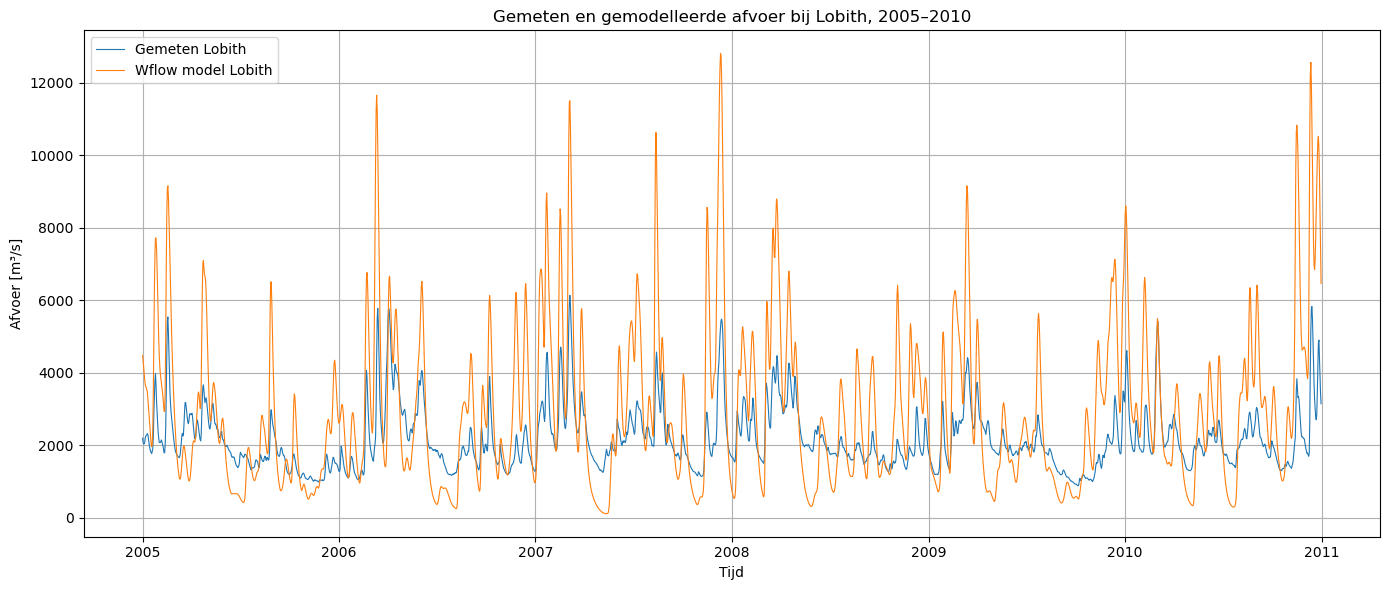

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["date"],
    comparison[obs_col],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    comparison["date"],
    comparison[sim_col],
    label="Wflow model Lobith",
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gemeten en gemodelleerde afvoer bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
calibration_data = comparison[
    (comparison["date"] >= "2005-01-01") &
    (comparison["date"] <= "2007-12-31")
].copy()

validation_data = comparison[
    (comparison["date"] >= "2008-01-01") &
    (comparison["date"] <= "2010-12-31")
].copy()

print("Kalibratieperiode:")
print(calibration_data["date"].min(), "tot", calibration_data["date"].max())
print("Aantal dagen:", len(calibration_data))

print("\nValidatieperiode:")
print(validation_data["date"].min(), "tot", validation_data["date"].max())
print("Aantal dagen:", len(validation_data))

Kalibratieperiode:
2005-01-01 00:00:00 tot 2007-12-31 00:00:00
Aantal dagen: 1095

Validatieperiode:
2008-01-01 00:00:00 tot 2010-12-31 00:00:00
Aantal dagen: 1096


In [16]:
def performance_scores(data, sim_col, obs_col="Q_mean_m3s", low_flow_limit=2000):
    obs = data[obs_col]
    sim = data[sim_col]
    
    rmse = np.sqrt(((sim - obs) ** 2).mean())
    bias = sim.mean() - obs.mean()
    correlation = obs.corr(sim)
    
    nse = 1 - ((sim - obs) ** 2).sum() / ((obs - obs.mean()) ** 2).sum()
    
    obs_low_days = (obs < low_flow_limit).sum()
    sim_low_days = (sim < low_flow_limit).sum()
    low_day_error = sim_low_days - obs_low_days
    
    low_data = data[obs < low_flow_limit]
    
    if len(low_data) > 0:
        low_rmse = np.sqrt(((low_data[sim_col] - low_data[obs_col]) ** 2).mean())
        low_bias = low_data[sim_col].mean() - low_data[obs_col].mean()
    else:
        low_rmse = np.nan
        low_bias = np.nan
    
    return {
        "RMSE": rmse,
        "Bias": bias,
        "Correlation": correlation,
        "NSE": nse,
        "Observed low-flow days": obs_low_days,
        "Simulated low-flow days": sim_low_days,
        "Low-flow day error": low_day_error,
        "Low-flow RMSE": low_rmse,
        "Low-flow bias": low_bias,
    }

In [17]:
scores_calibration_original = performance_scores(
    calibration_data,
    sim_col=sim_col,
    obs_col=obs_col,
    low_flow_limit=2000
)

scores_validation_original = performance_scores(
    validation_data,
    sim_col=sim_col,
    obs_col=obs_col,
    low_flow_limit=2000
)

print("Origineel model - kalibratieperiode")
for key, value in scores_calibration_original.items():
    print(key, ":", value)

print("\nOrigineel model - validatieperiode")
for key, value in scores_validation_original.items():
    print(key, ":", value)

Origineel model - kalibratieperiode
RMSE : 1778.593110701667
Bias : 747.3061955467929
Correlation : 0.8149188388591564
NSE : -2.676382416311135
Observed low-flow days : 570
Simulated low-flow days : 460
Low-flow day error : -110
Low-flow RMSE : 965.9587169224415
Low-flow bias : 42.92257866218074

Origineel model - validatieperiode
RMSE : 1803.0583100017668
Bias : 848.1599351367809
Correlation : 0.76578056104963
NSE : -4.486731319588138
Observed low-flow days : 585
Simulated low-flow days : 420
Low-flow day error : -165
Low-flow RMSE : 1089.4910225571532
Low-flow bias : 214.9467227077214


In [18]:
score_table = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},
])

score_table

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723


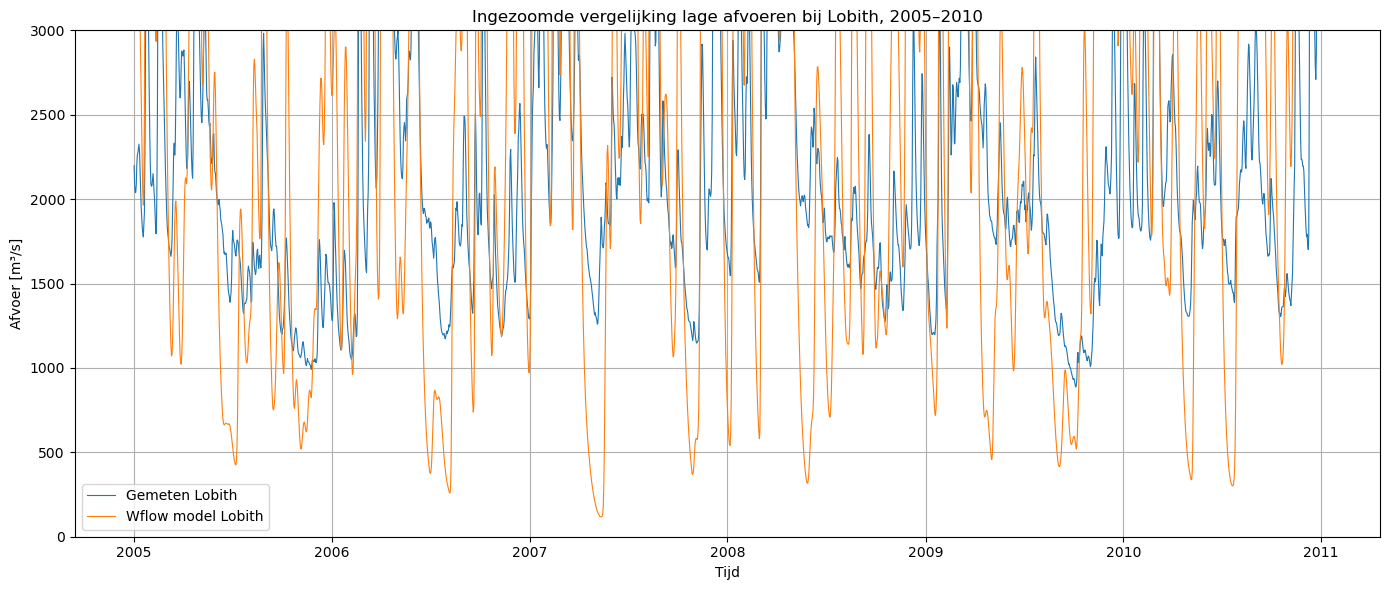

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["date"],
    comparison[obs_col],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    comparison["date"],
    comparison[sim_col],
    label="Wflow model Lobith",
    linewidth=0.8
)

plt.ylim(0, 3000)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Ingezoomde vergelijking lage afvoeren bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets

parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Parameter set directory:")
print(parameter_set.directory)

print("\nConfig:")
print(parameter_set.config)
print("Config bestaat:", parameter_set.config.exists())

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


Parameter set directory:
/data/shared/parameter-sets/wflow_rhine_sbm_nc

Config:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
Config bestaat: True


In [21]:
possible_staticmaps_dirs = [
    Path(parameter_set.directory) / "staticmaps",
    Path(parameter_set.directory) / "wflow_sbm_NC" / "staticmaps",
]

for folder in possible_staticmaps_dirs:
    print(folder)
    print("Bestaat:", folder.exists())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps
Bestaat: True
/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC/staticmaps
Bestaat: False


In [22]:
staticmaps_dir = Path(parameter_set.directory) / "staticmaps"

if not staticmaps_dir.exists():
    staticmaps_dir = Path(parameter_set.directory) / "wflow_sbm_NC" / "staticmaps"

print("Gebruikte staticmaps map:")
print(staticmaps_dir)
print("Bestaat:", staticmaps_dir.exists())

Gebruikte staticmaps map:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps
Bestaat: True


In [23]:
map_files = list(staticmaps_dir.glob("*.map"))

print("Aantal map-bestanden:", len(map_files))

for file in map_files:
    print(file.name)

Aantal map-bestanden: 31
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [24]:
keywords = [
    "ksat",
    "soil",
    "root",
    "theta",
    "m",
    "river",
    "n_",
    "mann",
    "infilt",
    "storage",
    "first",
    "second"
]

for file in map_files:
    name = file.name.lower()
    
    for key in keywords:
        if key in name:
            print(file.name)
            break

ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [25]:
staticmaps_dir = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps")

print("Gebruikte staticmaps map:")
print(staticmaps_dir)
print("Bestaat:", staticmaps_dir.exists())

Gebruikte staticmaps map:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps
Bestaat: True


In [26]:
map_files = sorted(list(staticmaps_dir.glob("*.map")))

print("Aantal map-bestanden:", len(map_files))

for file in map_files:
    print(file.name)

Aantal map-bestanden: 31
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [27]:
keywords = [
    "ksat",
    "soil",
    "root",
    "theta",
    "m",
    "river",
    "n_",
    "mann",
    "infilt",
    "storage",
    "first",
    "second",
    "path",
    "slope"
]

relevant_maps = []

for file in map_files:
    name = file.name.lower()
    
    for key in keywords:
        if key in name:
            relevant_maps.append(file.name)
            break

print("Mogelijk relevante parameterkaarten:")
for name in relevant_maps:
    print(name)

Mogelijk relevante parameterkaarten:
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [28]:
maps_table = pd.DataFrame({
    "filename": [file.name for file in map_files],
    "path": [str(file) for file in map_files]
})

maps_table

,filename,path
0,ChannelDepth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
1,DCL.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
2,RiverWidth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
3,cc.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
4,cutout.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
5,dem.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
6,gauges.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
7,tt.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
8,ttt.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
9,wflow_bankfulldepth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...


In [31]:
search_words = [
    "ksat",
    "soil",
    "thick",
    "root",
    "theta",
    "infilt",
    "n",
    "m",
    "river",
    "mann"
]

for word in search_words:
    print("\n--- Zoekterm:", word, "---")
    
    for file in map_files:
        if word.lower() in file.name.lower():
            print(file.name)


--- Zoekterm: ksat ---

--- Zoekterm: soil ---
wflow_soil.map

--- Zoekterm: thick ---

--- Zoekterm: root ---

--- Zoekterm: theta ---

--- Zoekterm: infilt ---

--- Zoekterm: n ---
ChannelDepth.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_demmin.map
wflow_landuse.map
wflow_riverburnin.map
wflow_riverlength_fact.map

--- Zoekterm: m ---
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map

--- Zoekterm: river ---
RiverWidth.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map

--- Zoekterm: mann ---


In [32]:
for file in map_files:
    print(file.name)

ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [33]:
print("Staticmaps dir:")
print(staticmaps_dir)

print("\nEerste 10 bestanden:")
for file in map_files[:10]:
    print(file)

Staticmaps dir:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps

Eerste 10 bestanden:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/ChannelDepth.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/DCL.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/RiverWidth.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/cc.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/cutout.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/dem.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/gauges.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/tt.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/ttt.map
/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_bankfulldepth.map


In [34]:
maps_table = pd.DataFrame({
    "filename": [file.name for file in map_files],
    "path": [str(file) for file in map_files]
})

maps_table

,filename,path
0,ChannelDepth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
1,DCL.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
2,RiverWidth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
3,cc.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
4,cutout.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
5,dem.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
6,gauges.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
7,tt.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
8,ttt.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...
9,wflow_bankfulldepth.map,/data/shared/parameter-sets/wflow_rhine_sbm_nc...


In [35]:
search_words = [
    "ksat",
    "soil",
    "theta",
    "root",
    "infilt",
    "m",
    "storage",
    "sat",
    "por",
    "gw",
    "sub",
    "water"
]

for word in search_words:
    print("\n--- Zoekterm:", word, "---")
    
    found = False
    
    for file in map_files:
        if word.lower() in file.name.lower():
            print(file.name)
            found = True
    
    if not found:
        print("Geen bestanden gevonden")


--- Zoekterm: ksat ---
Geen bestanden gevonden

--- Zoekterm: soil ---
wflow_soil.map

--- Zoekterm: theta ---
Geen bestanden gevonden

--- Zoekterm: root ---
Geen bestanden gevonden

--- Zoekterm: infilt ---
Geen bestanden gevonden

--- Zoekterm: m ---
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map

--- Zoekterm: storage ---
Geen bestanden gevonden

--- Zoekterm: sat ---
Geen bestanden gevonden

--- Zoekterm: por ---
Geen bestanden gevonden

--- Zoekterm: gw ---
Geen bestanden gevonden

--- Zoekterm: sub ---
wflow_subcatch.map

--- Zoekterm: water ---
G

In [36]:
config_file = Path(parameter_set.config)

with open(config_file, "r") as f:
    config_text = f.read()

search_terms = [
    "Ksat",
    "Soil",
    "Root",
    "theta",
    "Infilt",
    "M",
    "N",
    "ChannelDepth",
    "RiverWidth",
    "bankfull",
    "staticmaps"
]

for term in search_terms:
    print("\n---", term, "---")
    
    found = False
    
    for line in config_text.splitlines():
        if term.lower() in line.lower():
            print(line)
            found = True
    
    if not found:
        print("Niet gevonden")


--- Ksat ---
Niet gevonden

--- Soil ---
Niet gevonden

--- Root ---
# RootingDepth=monthlyclim/ROOT,monthyclim,100,1
#RootingDepth=monthlyclim/ROOT,monthlyclim,75,1

--- theta ---
Niet gevonden

--- Infilt ---
Niet gevonden

--- M ---
# Define the forcings needed for the model here
# the filename is either the name of the pcraster map-stack or the name of the 
[inputmapstacks]
Precipitation = /inmaps/P
EvapoTranspiration = /inmaps/PET
Temperature = /inmaps/TEMP
Inflow = /inmaps/IF 
[modelparameters]
# Format:
# name=stack,type,default
# example:
# RootingDepth=monthlyclim/ROOT,monthyclim,100,1
# - name - Name of the parameter (internal variable)
# - stack - Name of the mapstack (representation on disk or in mem) relative to case
# - type - Type of parameter (default = static)
# - default - Default value if map/tbl is not present
# - staticmap: Read at startup from map 
# - statictbl: Read at startup from tbl
# - timeseries: read map for each timestep
# - monthlyclim: read a map corre

In [37]:
search_words = [
    "ksat",
    "soil",
    "theta",
    "root",
    "infilt",
    "m",
    "storage",
    "sat",
    "por",
    "gw",
    "sub",
    "water"
]

for word in search_words:
    print("\n--- Zoekterm:", word, "---")
    
    found = False
    
    for file in map_files:
        if word.lower() in file.name.lower():
            print(file.name)
            found = True
    
    if not found:
        print("Geen bestanden gevonden")


--- Zoekterm: ksat ---
Geen bestanden gevonden

--- Zoekterm: soil ---
wflow_soil.map

--- Zoekterm: theta ---
Geen bestanden gevonden

--- Zoekterm: root ---
Geen bestanden gevonden

--- Zoekterm: infilt ---
Geen bestanden gevonden

--- Zoekterm: m ---
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map

--- Zoekterm: storage ---
Geen bestanden gevonden

--- Zoekterm: sat ---
Geen bestanden gevonden

--- Zoekterm: por ---
Geen bestanden gevonden

--- Zoekterm: gw ---
Geen bestanden gevonden

--- Zoekterm: sub ---
wflow_subcatch.map

--- Zoekterm: water ---
G

In [38]:
config_file = Path(parameter_set.config)

print(config_file)
print("Config bestaat:", config_file.exists())

with open(config_file, "r") as f:
    config_text = f.read()

search_terms = [
    "ksat",
    "soil",
    "root",
    "theta",
    "infilt",
    "storage",
    "sat",
    "por",
    "gw",
    "sub",
    "river",
    "channel",
    "width",
    "depth",
    "bankfull",
    "landuse",
    "table",
    "tbl",
    "staticmaps"
]

for term in search_terms:
    print("\n---", term, "---")
    
    found = False
    
    for line in config_text.splitlines():
        if term.lower() in line.lower():
            print(line)
            found = True
    
    if not found:
        print("Niet gevonden")

/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
Config bestaat: True

--- ksat ---
Niet gevonden

--- soil ---
Niet gevonden

--- root ---
# RootingDepth=monthlyclim/ROOT,monthyclim,100,1
#RootingDepth=monthlyclim/ROOT,monthlyclim,75,1

--- theta ---
Niet gevonden

--- infilt ---
Niet gevonden

--- storage ---
Niet gevonden

--- sat ---
Niet gevonden

--- por ---
Niet gevonden

--- gw ---
Niet gevonden

--- sub ---
#SubCatchFlowOnly = 1
#self.SubCellFrac=scf

--- river ---
# Alpha for wiver-width estimation 5 for mountain stream 60 for the river rhine
self.RiverRunoff=run
self.RiverRunoff=run.tss

--- channel ---
Niet gevonden

--- width ---
# Alpha for wiver-width estimation 5 for mountain stream 60 for the river rhine

--- depth ---
# RootingDepth=monthlyclim/ROOT,monthyclim,100,1
#RootingDepth=monthlyclim/ROOT,monthlyclim,75,1

--- bankfull ---
Niet gevonden

--- landuse ---
samplemap=staticmaps/wflow_landuse.map

--- table ---
Niet gevonden

--- tbl ---
# - default 

In [39]:
param_dir = Path(parameter_set.directory)

print("Parameter set directory:")
print(param_dir)

for item in sorted(param_dir.iterdir()):
    print(item.name)

Parameter set directory:
/data/shared/parameter-sets/wflow_rhine_sbm_nc
inmaps.nc
instates.nc
intbl
intss
staticmaps
staticmaps.nc
wflow_sbm_NC.ini
wflow_sbm_NC2.ini


In [40]:
for item in sorted(param_dir.rglob("*")):
    if item.is_file():
        if item.suffix.lower() in [".tbl", ".csv", ".txt", ".ini", ".toml", ".nc"]:
            print(item)

/data/shared/parameter-sets/wflow_rhine_sbm_nc/inmaps.nc
/data/shared/parameter-sets/wflow_rhine_sbm_nc/instates.nc
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/CanopyGapFraction.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/Cfmax.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/EoverR.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/FirstZoneCapacity.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/FirstZoneKsatVer.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/FirstZoneMinCapacity.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/InfiltCapPath.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/InfiltCapSoil.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/M.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/MaxCanopyStorage.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/MaxLeakage.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/N.tbl
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl/

In [41]:
intbl_dir = Path(parameter_set.directory) / "intbl"

print("intbl map:")
print(intbl_dir)
print("Bestaat:", intbl_dir.exists())

intbl map:
/data/shared/parameter-sets/wflow_rhine_sbm_nc/intbl
Bestaat: True


In [42]:
tbl_files = sorted(list(intbl_dir.glob("*.tbl")))

print("Aantal tbl-bestanden:", len(tbl_files))

for file in tbl_files:
    print(file.name)

Aantal tbl-bestanden: 22
CanopyGapFraction.tbl
Cfmax.tbl
EoverR.tbl
FirstZoneCapacity.tbl
FirstZoneKsatVer.tbl
FirstZoneMinCapacity.tbl
InfiltCapPath.tbl
InfiltCapSoil.tbl
M.tbl
MaxCanopyStorage.tbl
MaxLeakage.tbl
N.tbl
N_Floodplain.tbl
N_River.tbl
PathFrac.tbl
RootingDepth.tbl
TT.tbl
TTI.tbl
WHC.tbl
cf_soil.tbl
thetaR.tbl
thetaS.tbl


In [43]:
important_tbls = [
    "M.tbl",
    "FirstZoneCapacity.tbl",
    "FirstZoneKsatVer.tbl",
    "InfiltCapSoil.tbl",
    "RootingDepth.tbl",
    "thetaS.tbl",
    "thetaR.tbl",
    "N_River.tbl",
    "N_Floodplain.tbl",
    "MaxLeakage.tbl",
]

for tbl_name in important_tbls:
    tbl_path = intbl_dir / tbl_name
    
    print("\n---", tbl_name, "---")
    print("Bestaat:", tbl_path.exists())
    
    if tbl_path.exists():
        with open(tbl_path, "r") as f:
            lines = f.readlines()
        
        for line in lines[:20]:
            print(line.strip())


--- M.tbl ---
Bestaat: True
<,7]	1	1 1504
<,7]	2	1 193
<,7]	3	1 12880
<,7]	4	1 183
<,7]	5	1 176
<,7]	6	1 183
<,7]	7	1 133
<,7]	8	1 1450
<,7]	9	1 183
<,7]	10	1  190
<,7]	11	1  1100
<,7]	12	1  17
<,7]	13	1  128
<,7]	14	1  17

--- FirstZoneCapacity.tbl ---
Bestaat: True
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200

--- FirstZoneKsatVer.tbl ---
Bestaat: True
<,7]	1  1  8000
<,7]	2  1  100
<,7]	3  1  100
<,7]	4  1  1000
<,7]	5  1  1000
<,7]	6  1  1000
<,7]	7  1  1500
<,7]	8  1  100
<,7]	9  1  1000
<,7]	10 1  1000
<,7]	11 1  750
<,7]	12 1  4000
<,7]	13 1  1500
<,7]	14 1  8000

--- InfiltCapSoil.tbl ---
Bestaat: True
1 <,14]	1 5000
2 <,14]	1 5000
3 <,14]	1 5000
4 <,14]	1 5000
5 <,14]	1 5000
6 <,14]	1 5000

--- RootingDepth.tbl ---
Bestaat: True
1	1   	1 2
2	1	1 84
3	1	1 245
4	1	1 140
5	1	1 84
6	1	1 2
1	2	1 2
2	2	1 84

In [45]:
tbl_path = intbl_dir / "M.tbl"

M_table = pd.read_csv(
    tbl_path,
    sep=r"\s+",
    header=None,
    comment="#"
)

M_table

,0,1,2,3
0,"<,7]",1,1,1504
1,"<,7]",2,1,193
2,"<,7]",3,1,12880
3,"<,7]",4,1,183
4,"<,7]",5,1,176
5,"<,7]",6,1,183
6,"<,7]",7,1,133
7,"<,7]",8,1,1450
8,"<,7]",9,1,183
9,"<,7]",10,1,190


In [46]:
def multiply_tbl_values(input_file, output_file, factor):
    input_file = Path(input_file)
    output_file = Path(output_file)
    
    new_lines = []
    
    with open(input_file, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        stripped = line.strip()
        
        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue
        
        parts = stripped.split()
        
        try:
            value = float(parts[-1])
            parts[-1] = str(value * factor)
            new_line = "\t".join(parts) + "\n"
            new_lines.append(new_line)
        except:
            new_lines.append(line)
    
    with open(output_file, "w") as f:
        f.writelines(new_lines)

In [47]:
test_dir = Path("/home/niels/BEP-Niels/test_tbl_scaling")
test_dir.mkdir(exist_ok=True)

original_tbl = intbl_dir / "N_River.tbl"
test_tbl = test_dir / "N_River_factor_1p2.tbl"

multiply_tbl_values(
    input_file=original_tbl,
    output_file=test_tbl,
    factor=1.2
)

print("Origineel:")
with open(original_tbl, "r") as f:
    for line in f.readlines()[:5]:
        print(line.strip())

print("\nAangepast:")
with open(test_tbl, "r") as f:
    for line in f.readlines()[:5]:
        print(line.strip())

Origineel:
<,7]	1	1 0.054
<,7]	2	1 0.036
<,7]	3	1 0.027
<,7]	4	1 0.18
<,7]	5	1 0.18

Aangepast:
<,7]	1	1	0.0648
<,7]	2	1	0.043199999999999995
<,7]	3	1	0.0324
<,7]	4	1	0.216
<,7]	5	1	0.216


In [49]:
from pathlib import Path
from ewatercycle.forcing import sources

WflowForcing = sources["WflowForcing"]

forcing_dir = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_forcing_ERA5_2004_2010_with_correct_dem/"
    "work/diagnostic/script"
)

forcing_file = forcing_dir / "wflow_ERA5_Rhine_2004_2011.nc"

print("Forcing directory bestaat:", forcing_dir.exists())
print("Forcing bestand bestaat:", forcing_file.exists())
print(forcing_file)

Forcing directory bestaat: True
Forcing bestand bestaat: True
/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script/wflow_ERA5_Rhine_2004_2011.nc


In [51]:
forcing = WflowForcing(
    start_time="2004-01-01T00:00:00Z",
    end_time="2011-01-01T00:00:00Z",
    directory=forcing_dir,
    shape=Path("/home/niels/BEP-Niels/Rhine/Rhine.shp"),
    netcdfinput="wflow_ERA5_Rhine_2004_2011.nc",
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print(forcing)

start_time='2004-01-01T00:00:00Z' end_time='2011-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_2004_2011.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None


In [52]:
from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets

parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()

print("cfg_file:", cfg_file)
print("cfg_dir:", cfg_dir)

run_intbl_dir = Path(cfg_dir) / "intbl"

print("Run intbl map:")
print(run_intbl_dir)
print("Bestaat:", run_intbl_dir.exists())

if run_intbl_dir.exists():
    for file in sorted(run_intbl_dir.glob("*.tbl")):
        print(file.name)

cfg_file: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_115825/wflow_ewatercycle.ini
cfg_dir: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_115825
Run intbl map:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_115825/intbl
Bestaat: True
CanopyGapFraction.tbl
Cfmax.tbl
EoverR.tbl
FirstZoneCapacity.tbl
FirstZoneKsatVer.tbl
FirstZoneMinCapacity.tbl
InfiltCapPath.tbl
InfiltCapSoil.tbl
M.tbl
MaxCanopyStorage.tbl
MaxLeakage.tbl
N.tbl
N_Floodplain.tbl
N_River.tbl
PathFrac.tbl
RootingDepth.tbl
TT.tbl
TTI.tbl
WHC.tbl
cf_soil.tbl
thetaR.tbl
thetaS.tbl


In [55]:
def multiply_tbl_values(input_file, output_file, factor):
    input_file = Path(input_file)
    output_file = Path(output_file)
    
    new_lines = []
    
    with open(input_file, "r") as f:
        lines = f.readlines()
    
    for line in lines:
        stripped = line.strip()
        
        if stripped == "" or stripped.startswith("#"):
            new_lines.append(line)
            continue
        
        parts = stripped.split()
        
        try:
            value = float(parts[-1])
            parts[-1] = str(value * factor)
            new_line = "\t".join(parts) + "\n"
            new_lines.append(new_line)
        except:
            new_lines.append(line)
    
    with open(output_file, "w") as f:
        f.writelines(new_lines)

In [56]:
test_dir = Path("/home/niels/BEP-Niels/test_tbl_scaling")
test_dir.mkdir(exist_ok=True)

original_tbl = run_intbl_dir / "N_River.tbl"
test_tbl = test_dir / "N_River_factor_1p2.tbl"

multiply_tbl_values(
    input_file=original_tbl,
    output_file=test_tbl,
    factor=1.2
)

print("Origineel:")
with open(original_tbl, "r") as f:
    for line in f.readlines()[:5]:
        print(line.strip())

print("\nAangepast:")
with open(test_tbl, "r") as f:
    for line in f.readlines()[:5]:
        print(line.strip())

Origineel:
<,7]	1	1 0.054
<,7]	2	1 0.036
<,7]	3	1 0.027
<,7]	4	1 0.18
<,7]	5	1 0.18

Aangepast:
<,7]	1	1	0.0648
<,7]	2	1	0.043199999999999995
<,7]	3	1	0.0324
<,7]	4	1	0.216
<,7]	5	1	0.216


In [57]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()

run_intbl_dir = Path(cfg_dir) / "intbl"

print("Nieuwe runmap:")
print(cfg_dir)

nriver_tbl = run_intbl_dir / "N_River.tbl"

print("N_River bestaat:", nriver_tbl.exists())

multiply_tbl_values(
    input_file=nriver_tbl,
    output_file=nriver_tbl,
    factor=1.2
)

print("N_River.tbl aangepast met factor 1.2")

model.initialize(cfg_file)

print("Model gestart met N_River × 1.2")

Nieuwe runmap:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_120522
N_River bestaat: True
N_River.tbl aangepast met factor 1.2
Model gestart met N_River × 1.2


In [58]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

In [59]:
Q_model_test = []
time_model_test = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model_test.append(float(q_lobith))
    time_model_test.append(model.time_as_datetime)

model_test = pd.DataFrame({
    "date": pd.to_datetime(time_model_test),
    "Q_model_Nriver_1p2_m3s": Q_model_test
})

print("Aantal modelstappen:", len(model_test))
print("Eerste datum:", model_test["date"].min())
print("Laatste datum:", model_test["date"].max())

model_test.head()

Aantal modelstappen: 2558
Eerste datum: 2004-01-01 00:00:00
Laatste datum: 2011-01-01 00:00:00


,date,Q_model_Nriver_1p2_m3s
0,2004-01-01,0.000470
1,2004-01-02,0.000328
2,2004-01-03,0.000230
3,2004-01-04,0.000996
4,2004-01-05,0.001099


In [60]:
model_test_validation = model_test[
    (model_test["date"] >= "2005-01-01") &
    (model_test["date"] <= "2010-12-31")
].copy()

print("Aantal validatiedagen:", len(model_test_validation))
print("Eerste datum:", model_test_validation["date"].min())
print("Laatste datum:", model_test_validation["date"].max())

Aantal validatiedagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


In [61]:
comparison_test = pd.merge(
    comparison,
    model_test_validation,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison_test))
comparison_test.head()

Aantal overlappende dagen: 2191


,date,Q_mean_m3s,Q_model_m3s,Q_model_Nriver_1p2_m3s
0,2005-01-01,2198.041667,4478.155762,4542.470215
1,2005-01-02,2084.208333,4328.943359,4395.039062
2,2005-01-03,2039.416667,4163.805176,4244.033203
3,2005-01-04,2041.000000,3979.241455,4082.385986
4,2005-01-05,2085.541667,3801.807129,3921.366699


In [62]:
scores_Nriver_1p2_calibration = performance_scores(
    comparison_test[
        (comparison_test["date"] >= "2005-01-01") &
        (comparison_test["date"] <= "2007-12-31")
    ],
    sim_col="Q_model_Nriver_1p2_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

scores_Nriver_1p2_validation = performance_scores(
    comparison_test[
        (comparison_test["date"] >= "2008-01-01") &
        (comparison_test["date"] <= "2010-12-31")
    ],
    sim_col="Q_model_Nriver_1p2_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

print("N_River × 1.2 - kalibratieperiode")
for key, value in scores_Nriver_1p2_calibration.items():
    print(key, ":", value)

print("\nN_River × 1.2 - validatieperiode")
for key, value in scores_Nriver_1p2_validation.items():
    print(key, ":", value)

N_River × 1.2 - kalibratieperiode
RMSE : 1724.322972756135
Bias : 749.8746600611203
Correlation : 0.8145662524862027
NSE : -2.4554506688551188
Observed low-flow days : 570
Simulated low-flow days : 448
Low-flow day error : -122
Low-flow RMSE : 960.8619884963878
Low-flow bias : 74.83654535304731

N_River × 1.2 - validatieperiode
RMSE : 1758.5752366405147
Bias : 843.6735815340585
Correlation : 0.7671197940935731
NSE : -4.219345624853071
Observed low-flow days : 585
Simulated low-flow days : 412
Low-flow day error : -173
Low-flow RMSE : 1062.999177491068
Low-flow bias : 239.94204929275747


In [63]:
score_table_extra = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},
    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},
])

score_table_extra

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049


FIRSTZONE CAPACITY TEST

In [64]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()

run_intbl_dir = Path(cfg_dir) / "intbl"

print("Nieuwe runmap:")
print(cfg_dir)

fzc_tbl = run_intbl_dir / "FirstZoneCapacity.tbl"

print("FirstZoneCapacity bestaat:", fzc_tbl.exists())

multiply_tbl_values(
    input_file=fzc_tbl,
    output_file=fzc_tbl,
    factor=0.75
)

print("FirstZoneCapacity.tbl aangepast met factor 0.75")

model.initialize(cfg_file)

print("Model gestart met FirstZoneCapacity × 0.75")

Nieuwe runmap:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_122740
FirstZoneCapacity bestaat: True
FirstZoneCapacity.tbl aangepast met factor 0.75
Model gestart met FirstZoneCapacity × 0.75


In [65]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

In [66]:
Q_model_test = []
time_model_test = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model_test.append(float(q_lobith))
    time_model_test.append(model.time_as_datetime)

model_test_fzc_075 = pd.DataFrame({
    "date": pd.to_datetime(time_model_test),
    "Q_model_FZC_0p75_m3s": Q_model_test
})

print("Aantal modelstappen:", len(model_test_fzc_075))
print("Eerste datum:", model_test_fzc_075["date"].min())
print("Laatste datum:", model_test_fzc_075["date"].max())

model_test_fzc_075.head()

Aantal modelstappen: 2558
Eerste datum: 2004-01-01 00:00:00
Laatste datum: 2011-01-01 00:00:00


,date,Q_model_FZC_0p75_m3s
0,2004-01-01,0.000528
1,2004-01-02,0.000370
2,2004-01-03,0.000261
3,2004-01-04,0.001124
4,2004-01-05,0.001245


In [67]:
model_test_fzc_075_validation = model_test_fzc_075[
    (model_test_fzc_075["date"] >= "2005-01-01") &
    (model_test_fzc_075["date"] <= "2010-12-31")
].copy()

print("Aantal validatiedagen:", len(model_test_fzc_075_validation))
print("Eerste datum:", model_test_fzc_075_validation["date"].min())
print("Laatste datum:", model_test_fzc_075_validation["date"].max())

Aantal validatiedagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


In [68]:
comparison_fzc_075 = pd.merge(
    comparison,
    model_test_fzc_075_validation,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison_fzc_075))

comparison_fzc_075.head()

Aantal overlappende dagen: 2191


,date,Q_mean_m3s,Q_model_m3s,Q_model_FZC_0p75_m3s
0,2005-01-01,2198.041667,4478.155762,4478.155762
1,2005-01-02,2084.208333,4328.943359,4328.943359
2,2005-01-03,2039.416667,4163.805176,4163.805176
3,2005-01-04,2041.000000,3979.241455,3979.241455
4,2005-01-05,2085.541667,3801.807129,3801.807129


In [69]:
scores_fzc_075_calibration = performance_scores(
    comparison_fzc_075[
        (comparison_fzc_075["date"] >= "2005-01-01") &
        (comparison_fzc_075["date"] <= "2007-12-31")
    ],
    sim_col="Q_model_FZC_0p75_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

scores_fzc_075_validation = performance_scores(
    comparison_fzc_075[
        (comparison_fzc_075["date"] >= "2008-01-01") &
        (comparison_fzc_075["date"] <= "2010-12-31")
    ],
    sim_col="Q_model_FZC_0p75_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

print("FirstZoneCapacity × 0.75 - kalibratieperiode")
for key, value in scores_fzc_075_calibration.items():
    print(key, ":", value)

print("\nFirstZoneCapacity × 0.75 - validatieperiode")
for key, value in scores_fzc_075_validation.items():
    print(key, ":", value)

FirstZoneCapacity × 0.75 - kalibratieperiode
RMSE : 1778.593110701667
Bias : 747.3061955467929
Correlation : 0.8149188388591564
NSE : -2.676382416311135
Observed low-flow days : 570
Simulated low-flow days : 460
Low-flow day error : -110
Low-flow RMSE : 965.9587169224415
Low-flow bias : 42.92257866218074

FirstZoneCapacity × 0.75 - validatieperiode
RMSE : 1803.0583100017668
Bias : 848.1599351367809
Correlation : 0.76578056104963
NSE : -4.486731319588138
Observed low-flow days : 585
Simulated low-flow days : 420
Low-flow day error : -165
Low-flow RMSE : 1089.4910225571532
Low-flow bias : 214.9467227077214


In [70]:
score_table_fzc_075 = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},
    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},
    {"periode": "kalibratie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_calibration},
    {"periode": "validatie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_validation},
])

score_table_fzc_075

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049
4,kalibratie,FirstZoneCapacity x 0.75,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
5,validatie,FirstZoneCapacity x 0.75,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723


In [71]:
diff_fzc = (
    comparison_fzc_075["Q_model_FZC_0p75_m3s"] 
    - comparison_fzc_075["Q_model_m3s"]
)

print("Maximaal verschil:", diff_fzc.abs().max())
print("Gemiddeld verschil:", diff_fzc.abs().mean())

Maximaal verschil: 4.547473508864641e-13
Gemiddeld verschil: 6.100095326174115e-14


In [73]:
cfg_file_path = Path(cfg_file)

print("Config file:")
print(cfg_file_path)
print("Bestaat:", cfg_file_path.exists())

with open(cfg_file_path, "r") as f:
    cfg_text = f.read()

print(cfg_text[:500])

Config file:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_122740/wflow_ewatercycle.ini
Bestaat: True
[inputmapstacks]
Precipitation = /pr
EvapoTranspiration = /pet
Temperature = /tas
Inflow = /inmaps/IF

[modelparameters]

[run]
starttime = 2004-01-01 00:00:00
endtime = 2011-01-01 00:00:00
timestepsecs = 86400
reinit = 1

[model]
modeltype = sbm
AnnualDischarge = 2290
Alpha = 120
ModelSnow = 0
ScalarInput = 0
InterpolationMethod = inv
WIMaxScale = 0.8
Tslice = 1
UpdMaxDist = 300000.0
origTopogLateral = 1

[misc]

[framework]
netcdfoutput = outmaps.nc
netcdfinput = wflow_ERA5_Rhine_2004_2011.nc



In [74]:
for term in ["FirstZoneCapacity", "staticmaps.nc", "intbl", "tbl", "N_River", "M"]:
    print("\n---", term, "---")
    
    found = False
    
    for line in cfg_text.splitlines():
        if term.lower() in line.lower():
            print(line)
            found = True
    
    if not found:
        print("Niet gevonden")


--- FirstZoneCapacity ---
Niet gevonden

--- staticmaps.nc ---
Niet gevonden

--- intbl ---
Niet gevonden

--- tbl ---
Niet gevonden

--- N_River ---
Niet gevonden

--- M ---
[inputmapstacks]
Temperature = /tas
Inflow = /inmaps/IF
[modelparameters]
starttime = 2004-01-01 00:00:00
endtime = 2011-01-01 00:00:00
timestepsecs = 86400
[model]
modeltype = sbm
ModelSnow = 0
InterpolationMethod = inv
WIMaxScale = 0.8
UpdMaxDist = 300000.0
[misc]
[framework]
netcdfoutput = outmaps.nc
sizeinmetres = 0
[outputmaps]
self.InwaterMM = iwm
[summary]
self.MaxLeakage = MaxLeakage.map
[summary_sum]
self.Precipitation = Sumprecip.map
[summary_max]
self.Precipitation = maxprecip.map
[summary_min]
[summary_avg]
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
samplemap = staticmaps/wflow_gauges.map
RiverRunoff = 2, m/s


In [75]:
for term in ["FirstZoneCapacity", "staticmaps.nc", "staticmaps", "intbl", "tbl", "N_River", "M"]:
    print("\n---", term, "---")
    
    found = False
    
    for line in cfg_text.splitlines():
        if term.lower() in line.lower():
            print(line)
            found = True
    
    if not found:
        print("Niet gevonden")


--- FirstZoneCapacity ---
Niet gevonden

--- staticmaps.nc ---
Niet gevonden

--- staticmaps ---
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
samplemap = staticmaps/wflow_gauges.map

--- intbl ---
Niet gevonden

--- tbl ---
Niet gevonden

--- N_River ---
Niet gevonden

--- M ---
[inputmapstacks]
Temperature = /tas
Inflow = /inmaps/IF
[modelparameters]
starttime = 2004-01-01 00:00:00
endtime = 2011-01-01 00:00:00
timestepsecs = 86400
[model]
modeltype = sbm
ModelSnow = 0
InterpolationMethod = inv
WIMaxScale = 0.8
UpdMaxDist = 300000.0
[misc]
[framework]
netcdfoutput = outmaps.nc
sizeinmetres = 0
[outputmaps]
self.InwaterMM = iwm
[summary]
self.MaxLeakage = MaxLeakage.map
[summary_sum]
self.Precipitation = Sumprecip.map
[summary_max]
self.Precipitation = maxprecip.map
[summary_min]
[summary_avg]
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
samplemap = staticmaps/wflow_gauges.map
Ri

In [76]:
staticmaps_nc = Path(cfg_dir) / "staticmaps.nc"

print(staticmaps_nc)
print("Bestaat:", staticmaps_nc.exists())

/home/niels/BEP-Niels/Data Lobith/wflow_20260515_122740/staticmaps.nc
Bestaat: True


In [77]:
static_ds = xr.open_dataset(staticmaps_nc)

print(static_ds.data_vars)


Data variables:
    crs                         |S1 1B ...
    wflow_bankfulldepth.map     (time, lat, lon) float32 126kB ...
    wflow_catchment.map         (time, lat, lon) float32 126kB ...
    wflow_dem.map               (time, lat, lon) float32 126kB ...
    wflow_dem10.map             (time, lat, lon) float32 126kB ...
    wflow_dem25.map             (time, lat, lon) float32 126kB ...
    wflow_dem33.map             (time, lat, lon) float32 126kB ...
    wflow_dem66.map             (time, lat, lon) float32 126kB ...
    wflow_dem75.map             (time, lat, lon) float32 126kB ...
    wflow_dem90.map             (time, lat, lon) float32 126kB ...
    wflow_demmax.map            (time, lat, lon) float32 126kB ...
    wflow_demmin.map            (time, lat, lon) float32 126kB ...
    wflow_gauges.map            (time, lat, lon) float32 126kB ...
    wflow_landuse.map           (time, lat, lon) float32 126kB ...
    wflow_ldd.map               (time, lat, lon) float32 126kB ...
   

In [78]:
for var in static_ds.data_vars:
    name = var.lower()
    
    if (
        "first" in name 
        or "zone" in name 
        or "capacity" in name
        or name == "m"
        or "ksat" in name
        or "soil" in name
        or "theta" in name
        or "root" in name
        or "river" in name
        or name == "n"
    ):
        print(var)

wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map


In [79]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()

run_intbl_dir = Path(cfg_dir) / "intbl"

print("Nieuwe runmap:")
print(cfg_dir)

m_tbl = run_intbl_dir / "M.tbl"

print("M.tbl bestaat:", m_tbl.exists())

multiply_tbl_values(
    input_file=m_tbl,
    output_file=m_tbl,
    factor=0.75
)

print("M.tbl aangepast met factor 0.75")

model.initialize(cfg_file)

print("Model gestart met M × 0.75")

Nieuwe runmap:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_124455
M.tbl bestaat: True
M.tbl aangepast met factor 0.75
Model gestart met M × 0.75


In [80]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

Q_model_test = []
time_model_test = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model_test.append(float(q_lobith))
    time_model_test.append(model.time_as_datetime)

model_test_m_075 = pd.DataFrame({
    "date": pd.to_datetime(time_model_test),
    "Q_model_M_0p75_m3s": Q_model_test
})

print("Aantal modelstappen:", len(model_test_m_075))
print("Eerste datum:", model_test_m_075["date"].min())
print("Laatste datum:", model_test_m_075["date"].max())

model_test_m_075.head()

Aantal modelstappen: 2558
Eerste datum: 2004-01-01 00:00:00
Laatste datum: 2011-01-01 00:00:00


,date,Q_model_M_0p75_m3s
0,2004-01-01,0.000527
1,2004-01-02,0.000368
2,2004-01-03,0.000259
3,2004-01-04,0.001119
4,2004-01-05,0.001239


In [81]:
model_test_m_075_validation = model_test_m_075[
    (model_test_m_075["date"] >= "2005-01-01") &
    (model_test_m_075["date"] <= "2010-12-31")
].copy()

print("Aantal validatiedagen:", len(model_test_m_075_validation))
print("Eerste datum:", model_test_m_075_validation["date"].min())
print("Laatste datum:", model_test_m_075_validation["date"].max())

Aantal validatiedagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


In [82]:
comparison_m_075 = pd.merge(
    comparison,
    model_test_m_075_validation,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison_m_075))

comparison_m_075.head()

Aantal overlappende dagen: 2191


,date,Q_mean_m3s,Q_model_m3s,Q_model_M_0p75_m3s
0,2005-01-01,2198.041667,4478.155762,4486.384277
1,2005-01-02,2084.208333,4328.943359,4336.431641
2,2005-01-03,2039.416667,4163.805176,4170.479980
3,2005-01-04,2041.000000,3979.241455,3985.131348
4,2005-01-05,2085.541667,3801.807129,3807.044922


In [83]:
scores_m_075_calibration = performance_scores(
    comparison_m_075[
        (comparison_m_075["date"] >= "2005-01-01") &
        (comparison_m_075["date"] <= "2007-12-31")
    ],
    sim_col="Q_model_M_0p75_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

scores_m_075_validation = performance_scores(
    comparison_m_075[
        (comparison_m_075["date"] >= "2008-01-01") &
        (comparison_m_075["date"] <= "2010-12-31")
    ],
    sim_col="Q_model_M_0p75_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

print("M × 0.75 - kalibratieperiode")
for key, value in scores_m_075_calibration.items():
    print(key, ":", value)

print("\nM × 0.75 - validatieperiode")
for key, value in scores_m_075_validation.items():
    print(key, ":", value)

M × 0.75 - kalibratieperiode
RMSE : 1779.6608080725446
Bias : 747.796944365944
Correlation : 0.8147759290970245
NSE : -2.680797638649846
Observed low-flow days : 570
Simulated low-flow days : 460
Low-flow day error : -110
Low-flow RMSE : 966.9406224511216
Low-flow bias : 43.2591737758346

M × 0.75 - validatieperiode
RMSE : 1804.2379126978683
Bias : 848.6690376170359
Correlation : 0.7658093594533631
NSE : -4.493912762519056
Observed low-flow days : 585
Simulated low-flow days : 420
Low-flow day error : -165
Low-flow RMSE : 1089.238276018211
Low-flow bias : 214.43669358821353


In [84]:
score_table_m_075 = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},
    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},
    {"periode": "kalibratie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_calibration},
    {"periode": "validatie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_validation},
    {"periode": "kalibratie", "model": "M x 0.75", **scores_m_075_calibration},
    {"periode": "validatie", "model": "M x 0.75", **scores_m_075_validation},
])

score_table_m_075

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049
4,kalibratie,FirstZoneCapacity x 0.75,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
5,validatie,FirstZoneCapacity x 0.75,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
6,kalibratie,M x 0.75,1779.660808,747.796944,0.814776,-2.680798,570,460,-110,966.940622,43.259174
7,validatie,M x 0.75,1804.237913,848.669038,0.765809,-4.493913,585,420,-165,1089.238276,214.436694


In [85]:
diff_m = (
    comparison_m_075["Q_model_M_0p75_m3s"] 
    - comparison_m_075["Q_model_m3s"]
)

print("Maximaal verschil:", diff_m.abs().max())
print("Gemiddeld verschil:", diff_m.abs().mean())

Maximaal verschil: 90.57177734375
Gemiddeld verschil: 1.7751297874572578


## Kalibratietest 4: RootingDepth × 1.25

In deze test wordt `RootingDepth.tbl` vermenigvuldigd met 1.25. Een grotere worteldiepte kan leiden tot meer evapotranspiratie en daardoor lagere afvoeren tijdens droge perioden. Dit is relevant omdat het originele model te weinig laagwaterdagen simuleert.

In [86]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()

run_intbl_dir = Path(cfg_dir) / "intbl"

print("Nieuwe runmap:")
print(cfg_dir)

root_tbl = run_intbl_dir / "RootingDepth.tbl"

print("RootingDepth.tbl bestaat:", root_tbl.exists())

multiply_tbl_values(
    input_file=root_tbl,
    output_file=root_tbl,
    factor=1.25
)

print("RootingDepth.tbl aangepast met factor 1.25")

model.initialize(cfg_file)

print("Model gestart met RootingDepth × 1.25")

Nieuwe runmap:
/home/niels/BEP-Niels/Data Lobith/wflow_20260515_125821
RootingDepth.tbl bestaat: True
RootingDepth.tbl aangepast met factor 1.25
Model gestart met RootingDepth × 1.25


In [87]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

Q_model_test = []
time_model_test = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model_test.append(float(q_lobith))
    time_model_test.append(model.time_as_datetime)

model_test_root_125 = pd.DataFrame({
    "date": pd.to_datetime(time_model_test),
    "Q_model_Root_1p25_m3s": Q_model_test
})

print("Aantal modelstappen:", len(model_test_root_125))
print("Eerste datum:", model_test_root_125["date"].min())
print("Laatste datum:", model_test_root_125["date"].max())

model_test_root_125.head()

Aantal modelstappen: 2558
Eerste datum: 2004-01-01 00:00:00
Laatste datum: 2011-01-01 00:00:00


,date,Q_model_Root_1p25_m3s
0,2004-01-01,0.000528
1,2004-01-02,0.000370
2,2004-01-03,0.000261
3,2004-01-04,0.001124
4,2004-01-05,0.001245


In [88]:
model_test_root_125_validation = model_test_root_125[
    (model_test_root_125["date"] >= "2005-01-01") &
    (model_test_root_125["date"] <= "2010-12-31")
].copy()

print("Aantal validatiedagen:", len(model_test_root_125_validation))
print("Eerste datum:", model_test_root_125_validation["date"].min())
print("Laatste datum:", model_test_root_125_validation["date"].max())

Aantal validatiedagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


In [89]:
comparison_root_125 = pd.merge(
    comparison,
    model_test_root_125_validation,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison_root_125))

comparison_root_125.head()

Aantal overlappende dagen: 2191


,date,Q_mean_m3s,Q_model_m3s,Q_model_Root_1p25_m3s
0,2005-01-01,2198.041667,4478.155762,4461.372070
1,2005-01-02,2084.208333,4328.943359,4313.791016
2,2005-01-03,2039.416667,4163.805176,4149.695801
3,2005-01-04,2041.000000,3979.241455,3965.640869
4,2005-01-05,2085.541667,3801.807129,3787.931641


In [90]:
scores_root_125_calibration = performance_scores(
    comparison_root_125[
        (comparison_root_125["date"] >= "2005-01-01") &
        (comparison_root_125["date"] <= "2007-12-31")
    ],
    sim_col="Q_model_Root_1p25_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

scores_root_125_validation = performance_scores(
    comparison_root_125[
        (comparison_root_125["date"] >= "2008-01-01") &
        (comparison_root_125["date"] <= "2010-12-31")
    ],
    sim_col="Q_model_Root_1p25_m3s",
    obs_col=obs_col,
    low_flow_limit=2000
)

print("RootingDepth × 1.25 - kalibratieperiode")
for key, value in scores_root_125_calibration.items():
    print(key, ":", value)

print("\nRootingDepth × 1.25 - validatieperiode")
for key, value in scores_root_125_validation.items():
    print(key, ":", value)

RootingDepth × 1.25 - kalibratieperiode
RMSE : 1766.8606265550093
Bias : 733.5654302634784
Correlation : 0.8158200973160513
NSE : -2.628039898306021
Observed low-flow days : 570
Simulated low-flow days : 461
Low-flow day error : -109
Low-flow RMSE : 958.6263310265604
Low-flow bias : 33.37166433947823

RootingDepth × 1.25 - validatieperiode
RMSE : 1794.2288242584352
Bias : 841.0892943500603
Correlation : 0.7667357134781785
NSE : -4.433126398112263
Observed low-flow days : 585
Simulated low-flow days : 420
Low-flow day error : -165
Low-flow RMSE : 1086.8657220196021
Low-flow bias : 210.70173520688672


In [91]:
score_table_root_125 = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},
    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},
    {"periode": "kalibratie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_calibration},
    {"periode": "validatie", "model": "FirstZoneCapacity x 0.75", **scores_fzc_075_validation},
    {"periode": "kalibratie", "model": "M x 0.75", **scores_m_075_calibration},
    {"periode": "validatie", "model": "M x 0.75", **scores_m_075_validation},
    {"periode": "kalibratie", "model": "RootingDepth x 1.25", **scores_root_125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.25", **scores_root_125_validation},
])

score_table_root_125

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049
4,kalibratie,FirstZoneCapacity x 0.75,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
5,validatie,FirstZoneCapacity x 0.75,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
6,kalibratie,M x 0.75,1779.660808,747.796944,0.814776,-2.680798,570,460,-110,966.940622,43.259174
7,validatie,M x 0.75,1804.237913,848.669038,0.765809,-4.493913,585,420,-165,1089.238276,214.436694
8,kalibratie,RootingDepth x 1.25,1766.860627,733.565430,0.815820,-2.628040,570,461,-109,958.626331,33.371664
9,validatie,RootingDepth x 1.25,1794.228824,841.089294,0.766736,-4.433126,585,420,-165,1086.865722,210.701735


In [92]:
diff_root = (
    comparison_root_125["Q_model_Root_1p25_m3s"] 
    - comparison_root_125["Q_model_m3s"]
)

print("Maximaal verschil:", diff_root.abs().max())
print("Gemiddeld verschil:", diff_root.abs().mean())

Maximaal verschil: 409.502197265625
Gemiddeld verschil: 10.404180870595889


In [93]:
def run_tbl_factor_test(tbl_name, factor, output_col):
    try:
        model.finalize()
    except:
        pass

    model_new = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )

    cfg_file_new, cfg_dir_new = model_new.setup()

    run_intbl_dir = Path(cfg_dir_new) / "intbl"
    tbl_path = run_intbl_dir / tbl_name

    print("Nieuwe runmap:", cfg_dir_new)
    print(tbl_name, "bestaat:", tbl_path.exists())

    multiply_tbl_values(
        input_file=tbl_path,
        output_file=tbl_path,
        factor=factor
    )

    print(tbl_name, "aangepast met factor", factor)

    model_new.initialize(cfg_file_new)

    Q_model_test = []
    time_model_test = []

    while model_new.time < model_new.end_time:
        model_new.update()

        q_lobith = model_new.get_value_at_coords(
            "RiverRunoff",
            lat=[lat_lobith_model],
            lon=[lon_lobith_model]
        )[0]

        Q_model_test.append(float(q_lobith))
        time_model_test.append(model_new.time_as_datetime)

    model_test = pd.DataFrame({
        "date": pd.to_datetime(time_model_test),
        output_col: Q_model_test
    })

    model_test_validation = model_test[
        (model_test["date"] >= "2005-01-01") &
        (model_test["date"] <= "2010-12-31")
    ].copy()

    comparison_new = pd.merge(
        comparison,
        model_test_validation,
        on="date",
        how="inner"
    )

    calib_part = comparison_new[
        (comparison_new["date"] >= "2005-01-01") &
        (comparison_new["date"] <= "2007-12-31")
    ]

    valid_part = comparison_new[
        (comparison_new["date"] >= "2008-01-01") &
        (comparison_new["date"] <= "2010-12-31")
    ]

    scores_calib = performance_scores(
        calib_part,
        sim_col=output_col,
        obs_col=obs_col,
        low_flow_limit=2000
    )

    scores_valid = performance_scores(
        valid_part,
        sim_col=output_col,
        obs_col=obs_col,
        low_flow_limit=2000
    )

    return comparison_new, scores_calib, scores_valid

In [95]:
comparison_root_150, scores_root_150_calibration, scores_root_150_validation = run_tbl_factor_test(
    tbl_name="RootingDepth.tbl",
    factor=1.50,
    output_col="Q_model_Root_1p50_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_132433
RootingDepth.tbl bestaat: True
RootingDepth.tbl aangepast met factor 1.5


In [96]:
score_table_root_150 = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},

    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},

    {"periode": "kalibratie", "model": "M x 0.75", **scores_m_075_calibration},
    {"periode": "validatie", "model": "M x 0.75", **scores_m_075_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.25", **scores_root_125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.25", **scores_root_125_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50", **scores_root_150_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50", **scores_root_150_validation},
])

score_table_root_150

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049
4,kalibratie,M x 0.75,1779.660808,747.796944,0.814776,-2.680798,570,460,-110,966.940622,43.259174
5,validatie,M x 0.75,1804.237913,848.669038,0.765809,-4.493913,585,420,-165,1089.238276,214.436694
6,kalibratie,RootingDepth x 1.25,1766.860627,733.565430,0.815820,-2.628040,570,461,-109,958.626331,33.371664
7,validatie,RootingDepth x 1.25,1794.228824,841.089294,0.766736,-4.433126,585,420,-165,1086.865722,210.701735
8,kalibratie,RootingDepth x 1.50,1763.082346,728.623788,0.816122,-2.612540,570,464,-106,956.403422,28.997682
9,validatie,RootingDepth x 1.50,1791.513102,838.110157,0.766886,-4.416692,585,420,-165,1086.072878,208.633176


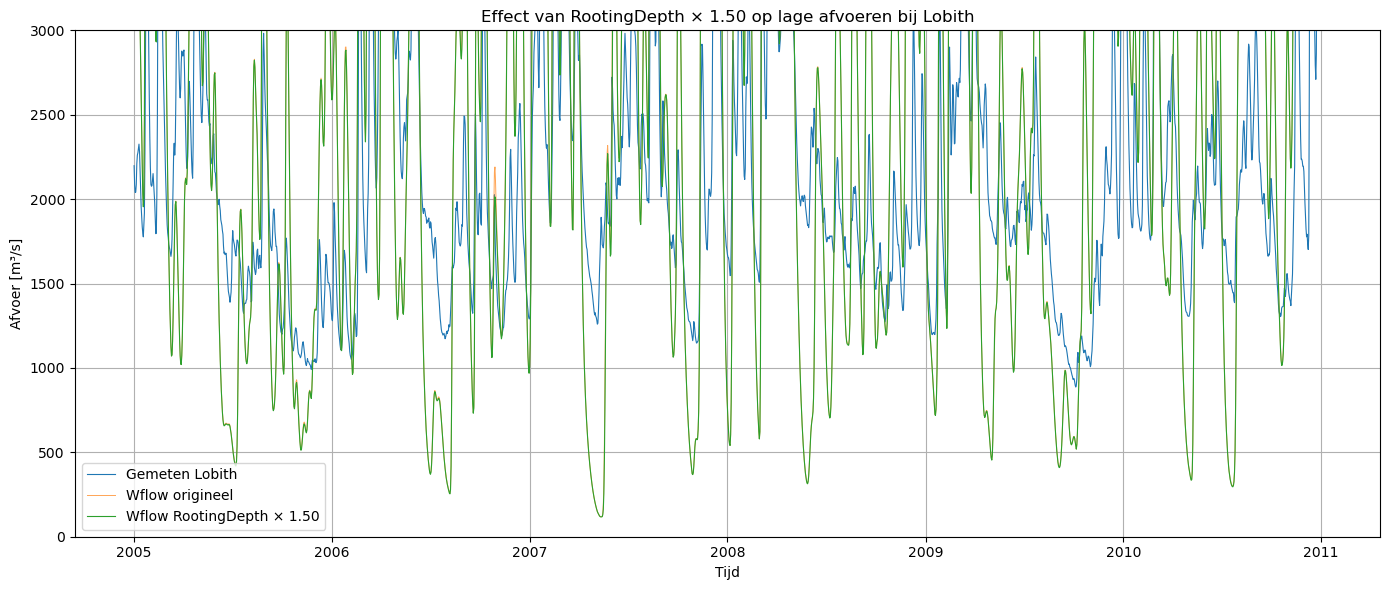

In [97]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_root_150["date"],
    comparison_root_150[obs_col],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    comparison_root_150["date"],
    comparison_root_150[sim_col],
    label="Wflow origineel",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    comparison_root_150["date"],
    comparison_root_150["Q_model_Root_1p50_m3s"],
    label="Wflow RootingDepth × 1.50",
    linewidth=0.8
)

plt.ylim(0, 3000)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Effect van RootingDepth × 1.50 op lage afvoeren bij Lobith")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Kalibratietest 5: EoverR * 1,25 ##

In [102]:
comparison_eoverr_125, scores_eoverr_125_calibration, scores_eoverr_125_validation = run_tbl_factor_test(
    tbl_name="EoverR.tbl",
    factor=1.25,
    output_col="Q_model_EoverR_1p25_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_135446
EoverR.tbl bestaat: True
EoverR.tbl aangepast met factor 1.25


In [103]:
score_table_eoverr_125 = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},

    {"periode": "kalibratie", "model": "N_River x 1.2", **scores_Nriver_1p2_calibration},
    {"periode": "validatie", "model": "N_River x 1.2", **scores_Nriver_1p2_validation},

    {"periode": "kalibratie", "model": "M x 0.75", **scores_m_075_calibration},
    {"periode": "validatie", "model": "M x 0.75", **scores_m_075_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.25", **scores_root_125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.25", **scores_root_125_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50", **scores_root_150_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50", **scores_root_150_validation},

    {"periode": "kalibratie", "model": "EoverR x 1.25", **scores_eoverr_125_calibration},
    {"periode": "validatie", "model": "EoverR x 1.25", **scores_eoverr_125_validation},
])

score_table_eoverr_125

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,N_River x 1.2,1724.322973,749.874660,0.814566,-2.455451,570,448,-122,960.861988,74.836545
3,validatie,N_River x 1.2,1758.575237,843.673582,0.767120,-4.219346,585,412,-173,1062.999177,239.942049
4,kalibratie,M x 0.75,1779.660808,747.796944,0.814776,-2.680798,570,460,-110,966.940622,43.259174
5,validatie,M x 0.75,1804.237913,848.669038,0.765809,-4.493913,585,420,-165,1089.238276,214.436694
6,kalibratie,RootingDepth x 1.25,1766.860627,733.565430,0.815820,-2.628040,570,461,-109,958.626331,33.371664
7,validatie,RootingDepth x 1.25,1794.228824,841.089294,0.766736,-4.433126,585,420,-165,1086.865722,210.701735
8,kalibratie,RootingDepth x 1.50,1763.082346,728.623788,0.816122,-2.612540,570,464,-106,956.403422,28.997682
9,validatie,RootingDepth x 1.50,1791.513102,838.110157,0.766886,-4.416692,585,420,-165,1086.072878,208.633176


In [104]:
def run_multiple_tbl_factor_test(tbl_factors, output_col):
    try:
        model.finalize()
    except:
        pass

    model_new = Wflow(
        parameter_set=parameter_set,
        forcing=forcing
    )

    cfg_file_new, cfg_dir_new = model_new.setup()

    run_intbl_dir = Path(cfg_dir_new) / "intbl"

    print("Nieuwe runmap:", cfg_dir_new)

    for tbl_name, factor in tbl_factors.items():
        tbl_path = run_intbl_dir / tbl_name

        print(tbl_name, "bestaat:", tbl_path.exists())
        print(tbl_name, "factor:", factor)

        multiply_tbl_values(
            input_file=tbl_path,
            output_file=tbl_path,
            factor=factor
        )

    model_new.initialize(cfg_file_new)

    Q_model_test = []
    time_model_test = []

    while model_new.time < model_new.end_time:
        model_new.update()

        q_lobith = model_new.get_value_at_coords(
            "RiverRunoff",
            lat=[lat_lobith_model],
            lon=[lon_lobith_model]
        )[0]

        Q_model_test.append(float(q_lobith))
        time_model_test.append(model_new.time_as_datetime)

    model_test = pd.DataFrame({
        "date": pd.to_datetime(time_model_test),
        output_col: Q_model_test
    })

    model_test_validation = model_test[
        (model_test["date"] >= "2005-01-01") &
        (model_test["date"] <= "2010-12-31")
    ].copy()

    comparison_new = pd.merge(
        comparison,
        model_test_validation,
        on="date",
        how="inner"
    )

    calib_part = comparison_new[
        (comparison_new["date"] >= "2005-01-01") &
        (comparison_new["date"] <= "2007-12-31")
    ]

    valid_part = comparison_new[
        (comparison_new["date"] >= "2008-01-01") &
        (comparison_new["date"] <= "2010-12-31")
    ]

    scores_calib = performance_scores(
        calib_part,
        sim_col=output_col,
        obs_col=obs_col,
        low_flow_limit=2000
    )

    scores_valid = performance_scores(
        valid_part,
        sim_col=output_col,
        obs_col=obs_col,
        low_flow_limit=2000
    )

    return comparison_new, scores_calib, scores_valid

In [105]:
comparison_root150_eoverr125, scores_root150_eoverr125_calibration, scores_root150_eoverr125_validation = run_multiple_tbl_factor_test(
    tbl_factors={
        "RootingDepth.tbl": 1.50,
        "EoverR.tbl": 1.25,
    },
    output_col="Q_model_Root1p50_EoverR1p25_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_140638
RootingDepth.tbl bestaat: True
RootingDepth.tbl factor: 1.5
EoverR.tbl bestaat: True
EoverR.tbl factor: 1.25


In [106]:
score_table_combined = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50", **scores_root_150_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50", **scores_root_150_validation},

    {"periode": "kalibratie", "model": "EoverR x 1.25", **scores_eoverr_125_calibration},
    {"periode": "validatie", "model": "EoverR x 1.25", **scores_eoverr_125_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_validation},
])

score_table_combined

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,RootingDepth x 1.50,1763.082346,728.623788,0.816122,-2.612540,570,464,-106,956.403422,28.997682
3,validatie,RootingDepth x 1.50,1791.513102,838.110157,0.766886,-4.416692,585,420,-165,1086.072878,208.633176
4,kalibratie,EoverR x 1.25,1770.306094,731.559497,0.814089,-2.642203,570,462,-108,964.033657,31.521717
5,validatie,EoverR x 1.25,1795.429569,832.403918,0.765376,-4.440401,585,422,-163,1086.185939,201.472233
6,kalibratie,RootingDepth x 1.50 + EoverR x 1.25,1754.299677,712.303623,0.815361,-2.576638,570,468,-102,954.081966,17.166033
7,validatie,RootingDepth x 1.50 + EoverR x 1.25,1783.653987,822.188434,0.766499,-4.369272,585,424,-161,1082.755034,195.144325


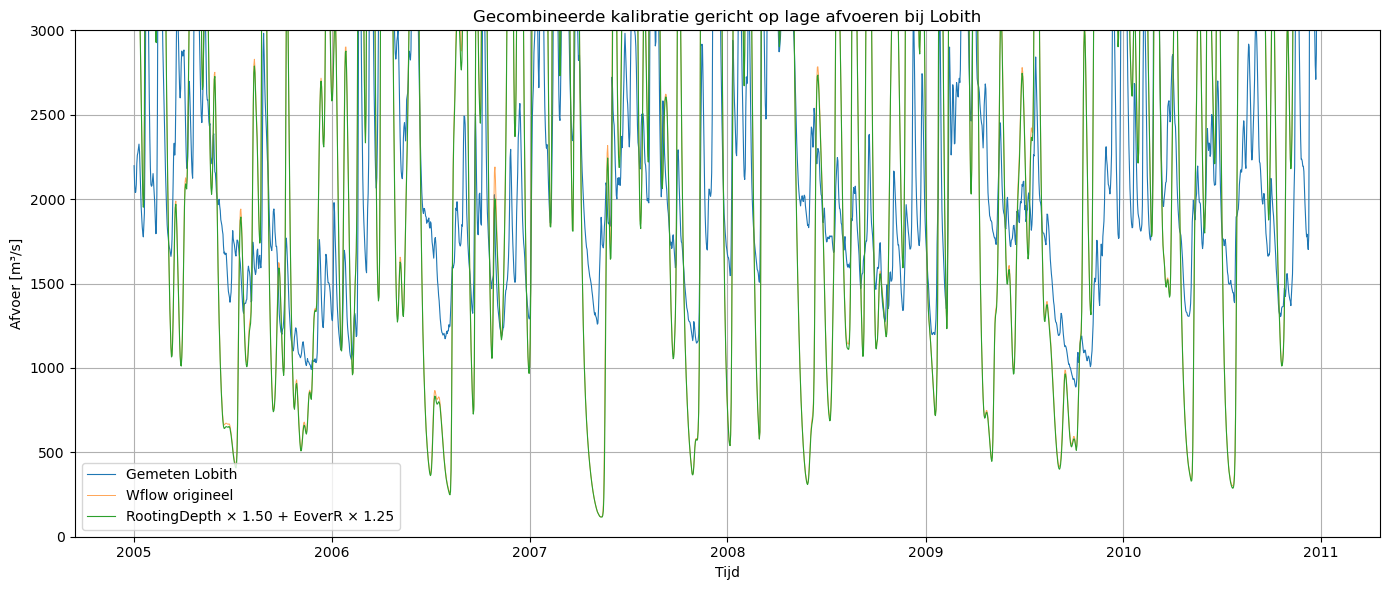

In [107]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_root150_eoverr125["date"],
    comparison_root150_eoverr125[obs_col],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    comparison_root150_eoverr125["date"],
    comparison_root150_eoverr125[sim_col],
    label="Wflow origineel",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    comparison_root150_eoverr125["date"],
    comparison_root150_eoverr125["Q_model_Root1p50_EoverR1p25_m3s"],
    label="RootingDepth × 1.50 + EoverR × 1.25",
    linewidth=0.8
)

plt.ylim(0, 3000)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gecombineerde kalibratie gericht op lage afvoeren bij Lobith")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [108]:
comparison_root150_eoverr150, scores_root150_eoverr150_calibration, scores_root150_eoverr150_validation = run_multiple_tbl_factor_test(
    tbl_factors={
        "RootingDepth.tbl": 1.50,
        "EoverR.tbl": 1.50,
    },
    output_col="Q_model_Root1p50_EoverR1p50_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_141846
RootingDepth.tbl bestaat: True
RootingDepth.tbl factor: 1.5
EoverR.tbl bestaat: True
EoverR.tbl factor: 1.5


In [109]:
comparison_root200_eoverr125, scores_root200_eoverr125_calibration, scores_root200_eoverr125_validation = run_multiple_tbl_factor_test(
    tbl_factors={
        "RootingDepth.tbl": 2.00,
        "EoverR.tbl": 1.25,
    },
    output_col="Q_model_Root2p00_EoverR1p25_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_142919
RootingDepth.tbl bestaat: True
RootingDepth.tbl factor: 2.0
EoverR.tbl bestaat: True
EoverR.tbl factor: 1.25


In [110]:
score_table_next = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.50", **scores_root150_eoverr150_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.50", **scores_root150_eoverr150_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 2.00 + EoverR x 1.25", **scores_root200_eoverr125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 2.00 + EoverR x 1.25", **scores_root200_eoverr125_validation},
])

score_table_next

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,RootingDepth x 1.50 + EoverR x 1.25,1754.299677,712.303623,0.815361,-2.576638,570,468,-102,954.081966,17.166033
3,validatie,RootingDepth x 1.50 + EoverR x 1.25,1783.653987,822.188434,0.766499,-4.369272,585,424,-161,1082.755034,195.144325
4,kalibratie,RootingDepth x 1.50 + EoverR x 1.50,1747.108941,698.203008,0.814639,-2.547378,570,469,-101,952.473075,6.959015
5,validatie,RootingDepth x 1.50 + EoverR x 1.50,1777.344813,808.526968,0.766164,-4.331354,585,426,-159,1080.306493,183.341999
6,kalibratie,RootingDepth x 2.00 + EoverR x 1.25,1752.012908,708.453547,0.815435,-2.567320,570,470,-100,953.413773,13.594943
7,validatie,RootingDepth x 2.00 + EoverR x 1.25,1781.545437,818.847710,0.766580,-4.356584,585,424,-161,1082.151865,192.304853


In [111]:
comparison_root150_eoverr175, scores_root150_eoverr175_calibration, scores_root150_eoverr175_validation = run_multiple_tbl_factor_test(
    tbl_factors={
        "RootingDepth.tbl": 1.50,
        "EoverR.tbl": 1.75,
    },
    output_col="Q_model_Root1p50_EoverR1p75_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_144058
RootingDepth.tbl bestaat: True
RootingDepth.tbl factor: 1.5
EoverR.tbl bestaat: True
EoverR.tbl factor: 1.75


In [112]:
comparison_root150_eoverr200, scores_root150_eoverr200_calibration, scores_root150_eoverr200_validation = run_multiple_tbl_factor_test(
    tbl_factors={
        "RootingDepth.tbl": 1.50,
        "EoverR.tbl": 2.00,
    },
    output_col="Q_model_Root1p50_EoverR2p00_m3s"
)

Nieuwe runmap: /home/niels/BEP-Niels/Data Lobith/wflow_20260515_145028
RootingDepth.tbl bestaat: True
RootingDepth.tbl factor: 1.5
EoverR.tbl bestaat: True
EoverR.tbl factor: 2.0


In [113]:
score_table_eoverr_range = pd.DataFrame([
    {"periode": "kalibratie", "model": "origineel", **scores_calibration_original},
    {"periode": "validatie", "model": "origineel", **scores_validation_original},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.25", **scores_root150_eoverr125_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.50", **scores_root150_eoverr150_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.50", **scores_root150_eoverr150_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 1.75", **scores_root150_eoverr175_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 1.75", **scores_root150_eoverr175_validation},

    {"periode": "kalibratie", "model": "RootingDepth x 1.50 + EoverR x 2.00", **scores_root150_eoverr200_calibration},
    {"periode": "validatie", "model": "RootingDepth x 1.50 + EoverR x 2.00", **scores_root150_eoverr200_validation},
])

score_table_eoverr_range

,periode,model,RMSE,Bias,Correlation,NSE,Observed low-flow days,Simulated low-flow days,Low-flow day error,Low-flow RMSE,Low-flow bias
0,kalibratie,origineel,1778.593111,747.306196,0.814919,-2.676382,570,460,-110,965.958717,42.922579
1,validatie,origineel,1803.058310,848.159935,0.765781,-4.486731,585,420,-165,1089.491023,214.946723
2,kalibratie,RootingDepth x 1.50 + EoverR x 1.25,1754.299677,712.303623,0.815361,-2.576638,570,468,-102,954.081966,17.166033
3,validatie,RootingDepth x 1.50 + EoverR x 1.25,1783.653987,822.188434,0.766499,-4.369272,585,424,-161,1082.755034,195.144325
4,kalibratie,RootingDepth x 1.50 + EoverR x 1.50,1747.108941,698.203008,0.814639,-2.547378,570,469,-101,952.473075,6.959015
5,validatie,RootingDepth x 1.50 + EoverR x 1.50,1777.344813,808.526968,0.766164,-4.331354,585,426,-159,1080.306493,183.341999
6,kalibratie,RootingDepth x 1.50 + EoverR x 1.75,1741.129152,685.959716,0.813974,-2.523136,570,472,-98,951.316855,-1.863344
7,validatie,RootingDepth x 1.50 + EoverR x 1.75,1772.166647,796.671037,0.765874,-4.300334,585,429,-156,1078.465018,172.940795
8,kalibratie,RootingDepth x 1.50 + EoverR x 2.00,1736.106568,675.270254,0.813371,-2.502839,570,475,-95,950.500093,-9.552732
9,validatie,RootingDepth x 1.50 + EoverR x 2.00,1767.868634,786.317403,0.765617,-4.274656,585,434,-151,1077.074444,163.725290


In [114]:
thresholds = [1000, 1250, 1500, 1750, 2000, 2250, 2500]

rows = []

for threshold in thresholds:
    obs_days = (validation_data[obs_col] < threshold).sum()
    sim_original_days = (validation_data[sim_col] < threshold).sum()
    
    sim_calibrated_days = (
        comparison_root150_eoverr200[
            (comparison_root150_eoverr200["date"] >= "2008-01-01") &
            (comparison_root150_eoverr200["date"] <= "2010-12-31")
        ]["Q_model_Root1p50_EoverR2p00_m3s"] < threshold
    ).sum()
    
    rows.append({
        "threshold_m3s": threshold,
        "observed_days": obs_days,
        "original_model_days": sim_original_days,
        "calibrated_model_days": sim_calibrated_days,
        "original_error": sim_original_days - obs_days,
        "calibrated_error": sim_calibrated_days - obs_days,
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,threshold_m3s,observed_days,original_model_days,calibrated_model_days,original_error,calibrated_error
0,1000,12,173,182,161,170
1,1250,71,243,257,172,186
2,1500,176,310,327,134,151
3,1750,328,372,387,44,59
4,2000,585,420,434,-165,-151
5,2250,728,475,489,-253,-239
6,2500,828,522,532,-306,-296


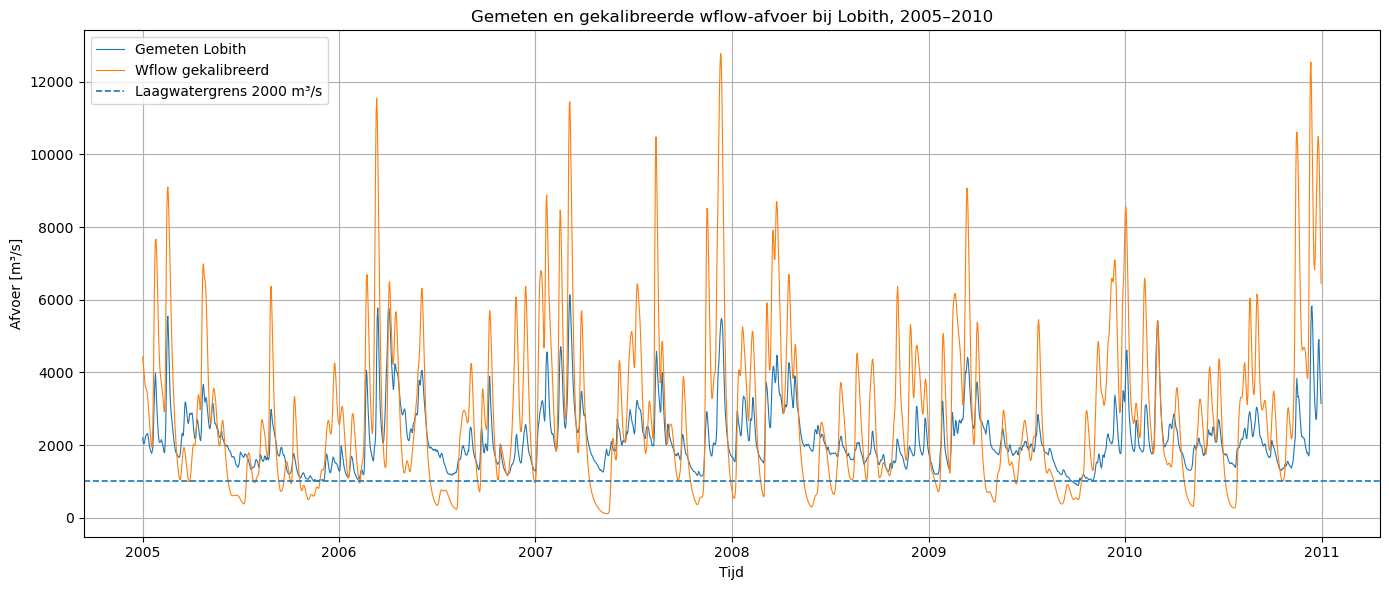

In [116]:
best_comparison = comparison_root150_eoverr200.copy()

best_model_col = "Q_model_Root1p50_EoverR2p00_m3s"
low_flow_limit = 1020

plt.figure(figsize=(14, 6))

plt.plot(
    best_comparison["date"],
    best_comparison[obs_col],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    best_comparison["date"],
    best_comparison[best_model_col],
    label="Wflow gekalibreerd",
    linewidth=0.8
)

plt.axhline(
    y=low_flow_limit,
    linestyle="--",
    linewidth=1.2,
    label="Laagwatergrens 2000 m³/s"
)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gemeten en gekalibreerde wflow-afvoer bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()